# Introduction to Python: a bimodal dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ewmcc/msacl-2026/blob/main/python-demo/python_demo.ipynb)

This notebook is a beginner's introduction to Python. In three short steps, we will:

1. **Generate** a made-up dataset with two peaks (a *bimodal* dataset)
2. **Summarize** it with its mean and standard deviation
3. **Plot** it as a histogram

Along the way you will meet the basic building blocks of Python: variables, lists, loops, functions, and packages.

## How to use this notebook

A notebook is made of **cells**. There are two kinds:
- **Text cells**, like this one, explain what is going on.
- **Code cells** hold Python code. When you run one, its output appears right below it.

To run a code cell in Google Colab, click it and press **Shift+Enter**, or click the ▶ button on its left. To run every cell at once, use **Runtime → Run all**.

Run the cells **from top to bottom**. Later cells use results from earlier ones.

> **Tip:** Colab already has every package this notebook uses (pandas and matplotlib), so there is nothing to install. The first cell you run may take a few seconds while Colab connects.

## 1. Generate the bimodal dataset

A **bimodal** dataset has two peaks. You see this when two groups are mixed together, for example, results from two different patient populations.

We will make our own: 50 values centered on 10, and 50 values centered on 20. Each value is drawn from a **normal (Gaussian) distribution** with a standard deviation of 2.

The cell below uses these Python ideas:

| Code | What it means |
|---|---|
| `# First mode: ...` | A **comment**. Python ignores everything after `#`. Comments are notes for people reading the code. |
| `import random` | Loads Python's built-in `random` **module**, a collection of tools for random numbers. We use its tools with a dot, as in `random.gauss(...)`. |
| `random.seed(123)` | Sets the starting point of the random number generator. With the same seed, you get the same "random" numbers every time, so your results match ours. |
| `data = []` | Creates a **variable** named `data` and stores an empty **list** in it. `=` means "store the value on the right under the name on the left". A list holds values in order. |
| `for _ in range(50):` | A **for loop**. It runs the indented lines below it 50 times. `range(50)` counts 0, 1, ..., 49. We don't need the count, so we name it `_`, which by convention means "not used". |
| Indentation | The 4 spaces at the start of a line show that it is **inside** the loop. Python uses indentation, not brackets, to group lines. |
| `random.gauss(10, 2)` | Calls a **function**: a named piece of code that does one job. This one returns a random number from a normal distribution with mean 10 and standard deviation 2. |
| `round(point, 3)` | Rounds a number to 3 decimal places. |
| `data.append(point)` | Adds `point` to the end of the list. |

The first loop takes two lines to make each point: one to draw it and one to round it. The second loop does both on one line: `round(random.gauss(20, 2), 3)`. Python runs the inner call first, then passes its result to `round`. Both forms do the same thing.

> **Tip:** All of the data is built in this one cell, starting from an empty list. So you can run it again (for example, after changing a number) and you will always get exactly 100 points.

In [1]:
import random

random.seed(123)

data = []

# First mode: mean=10, std=2
for _ in range(50):
    point = random.gauss(10, 2)
    point = round(point, 3)
    data.append(point)

# Second mode: mean=20, std=2
for _ in range(50):
    point = round(random.gauss(20, 2), 3)
    data.append(point)

Running the cell above printed nothing. It only stored the numbers in `data`. Now let's look at them.

`print(...)` shows a value below the cell. Text inside quotes, like `"Bimodal dataset:"`, is a **string**: a piece of text. If you give `print` several values separated by commas, it prints them on one line, with spaces between them.

`len(data)` gives the **length** of a list: how many items it holds. We should have 100.

The square brackets `[ ]` around the output show that `data` is a list.

In [2]:
print("Bimodal dataset:")
print(data)
print("Number of points:", len(data))

Bimodal dataset:
[10.808, 10.276, 9.203, 10.525, 10.454, 9.676, 8.249, 9.595, 10.706, 9.055, 9.061, 11.539, 10.004, 10.116, 9.211, 10.334, 9.377, 9.562, 9.128, 11.999, 10.731, 9.506, 12.215, 12.753, 14.362, 10.585, 8.594, 9.301, 11.795, 7.085, 8.007, 12.994, 10.734, 12.64, 6.411, 9.384, 9.196, 11.849, 10.29, 7.619, 8.864, 7.383, 7.898, 6.36, 7.039, 10.259, 9.641, 10.361, 10.033, 8.735, 21.89, 15.997, 19.333, 18.977, 18.965, 21.703, 21.979, 20.982, 18.378, 19.197, 20.321, 20.797, 19.778, 19.768, 19.138, 21.157, 16.857, 19.359, 22.402, 18.458, 25.151, 19.734, 19.002, 18.937, 18.756, 20.127, 22.166, 19.89, 20.006, 19.399, 20.868, 20.981, 19.926, 21.862, 19.707, 22.115, 19.158, 20.46, 21.73, 20.718, 21.808, 21.128, 22.474, 20.133, 22.756, 21.372, 15.209, 23.291, 19.822, 22.255]
Number of points: 100


## 2. Summarize the dataset

A long list of numbers is hard to read. **pandas** is a popular **package** for working with tables of data. A package is a library of code that someone else wrote and shared, so we don't have to write it ourselves.

| Code | What it means |
|---|---|
| `import pandas as pd` | Loads pandas and gives it the short name `pd`. Almost everyone uses `pd`, so you will see it in most examples online. |
| `pd.DataFrame(data, columns=['value'])` | Makes a **DataFrame**: a table with rows and named columns, like a spreadsheet. Our list becomes one column. |
| `columns=['value']` | A **keyword argument**: an extra input given by name. It names the column `value`. The names go in a list, even when there is only one. |

When you print a DataFrame this long, pandas shows the first 5 and last 5 rows, with `...` for the rows in between. The numbers on the left (0 to 99) are the **index**, the row labels. Like most counting in Python, they start at 0.

In [3]:
import pandas as pd

df = pd.DataFrame(data, columns=['value'])
print(df)

     value
0   10.808
1   10.276
2    9.203
3   10.525
4   10.454
..     ...
95  21.372
96  15.209
97  23.291
98  19.822
99  22.255

[100 rows x 1 columns]


Now we compute two summary statistics.

| Code | What it means |
|---|---|
| `df['value']` | Selects the `value` column from the table. |
| `.mean()` | A **method**: a function that belongs to a value and is called with a dot. This one returns the average of the column. |
| `.std()` | Returns the standard deviation. pandas uses the *sample* standard deviation (it divides by n − 1), the same as Excel's `STDEV.S`. |
| `round(mean, 3)` | The same `round` function as before, now used on our results. |
| `"\nSummary statistics:"` | `\n` inside a string means "start a new line". Here it adds a blank line before the heading. |

In [4]:
mean = df['value'].mean()
std_dev = df['value'].std()

print("\nSummary statistics:")
print("Mean:", round(mean, 3))
print("Standard Deviation:", round(std_dev, 3))


Summary statistics:
Mean: 15.079
Standard Deviation: 5.554


### What do these numbers tell us?

The mean is about **15**. But look back at the data: hardly any values are near 15. Only 4 of our 100 points fall between 13 and 17. The mean lands in the gap between the two groups.

The standard deviation is about **5.6**, much larger than the 2 we used to make each group. That's because it measures the spread of *both* groups together, including the distance between them.

So the mean and standard deviation alone hide the most important fact about this data: it has two peaks. To see that, we need to plot it.

## 3. Plot the data as a histogram

A **histogram** splits the range of values into equal-width **bins** and draws a bar for each one. The height of each bar is how many points fall in that bin.

**matplotlib** is Python's most widely used plotting package. pandas uses it to draw its plots.

| Code | What it means |
|---|---|
| `import matplotlib.pyplot as plt` | Loads matplotlib's plotting tools under the short name `plt`. |
| `df.plot.hist(y='value', bins=20)` | Draws a histogram of the `value` column, with 20 bins. |
| `ax = ...` | Stores the plot in `ax` (short for *axes*, matplotlib's name for one plot area), so we can add labels to it. |
| `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)` | Set the title, and the labels on the x (horizontal) and y (vertical) axes. |
| `plt.show()` | Shows the finished plot below the cell. |

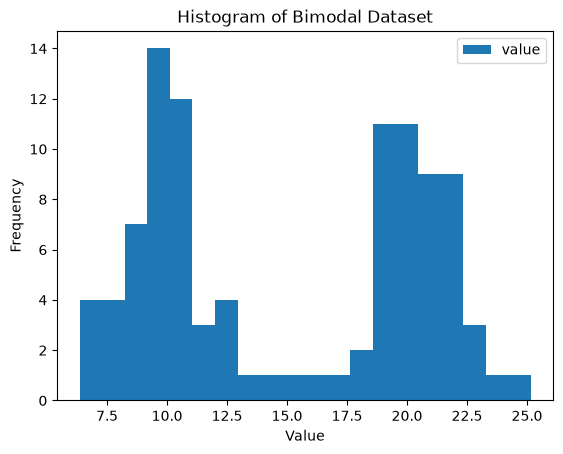

In [5]:
import matplotlib.pyplot as plt

ax = df.plot.hist(y='value', bins=20)
ax.set_title('Histogram of Bimodal Dataset')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
plt.show()

Now the two peaks are clear: one near 10 and one near 20, with a gap between them where the mean (15) sits. The plot shows at a glance what the summary statistics hid.